In [ ]:
#MUTIVARIATE ANALYSIS AND PREDICTION OF CH₄(METHANE) AND N₂O(NITROUS OXIDE) EMISSIONS ACROSS COUNTRIES

'''
How do per-capita CH₄ and N₂O emissions vary across countries and world regions, 
and how effectively can emission reduction status—defined as a binary indicator of 
whether a country has reduced emissions since 1990—be predicted using per-capita emissions and geographic classification?
'''

In [69]:
#importing tidyverse library to enable data acquisition ,data manipulation and visualization through its packages
library(tidyverse)

In [86]:
#Data Acquisition
df <- read.csv("CH4_N2O_Emissions.csv", 
               stringsAsFactors = FALSE,
               na.strings = c("...", "", "NA")) %>%
  as_tibble()

In [71]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [72]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA


In [73]:
tail(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [74]:
#Data Schema and variable definitions
dim(df)

[1] 204   9

In [16]:
#Columns
names(df)

[1] "Country"                  "latest.year.available"   
[3] "CH4.emissions"            "CH4.emissions.per.capita"
[5] "X..change.since.1990"     "N2O.emissions"           
[7] "N2O.emissions.per.capita" "X..change.since.1990.1"  
[9] "X"

In [17]:
#dat types and internal structure
glimpse(df)

Rows: 204
Columns: 9
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <chr> "0.42", "0.68", "1.06", "1.11", "1.83", "2.29…
$ X..change.since.1990     <chr> "...", "...", "...", "...", "43.74", "10.50",…
$ N2O.emissions            <chr> "5.94", "0.29", "6.50", "13.87", "0.08", "67.…
$ N2O.emissions.per.capita <chr> "0.24", "0.09", "0.21", "0.77", "1.08", "1.82…
$ X..change.since.1990.1   <chr> "...", "...", "...", "...", "5197.47", "30.26…
$ X                        <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


In [89]:
#Converting data type of N20.emissions from character to double for numerical operations
df$N2O.emissions <- as.double(df$N2O.emissions)

In [92]:
#Converting data type of N20.emissions.per.capita from character to double for numerical operations
df$N2O.emissions.per.capita <- as.double(df$N2O.emissions.per.capita)

In [29]:
#Data Quality Assessment to check missing values
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                       20                       20 
CH4.emissions.per.capita     X..change.since.1990            N2O.emissions 
                       0                        0                        0 
N2O.emissions.per.capita   X..change.since.1990.1                        X 
                       0                        0                      204

In [64]:
#Basic descriptive statistics
summary(df)

   Country          latest.year.available CH4.emissions    
 Length:204         Min.   :1990          Min.   :  0.000  
 Class :character   1st Qu.:2000          1st Qu.:  1.290  
 Mode  :character   Median :2000          Median :  5.075  
                    Mean   :2003          Mean   : 30.878  
                    3rd Qu.:2010          3rd Qu.: 20.430  
                    Max.   :2012          Max.   :932.860  
                    NA's   :20            NA's   :20       
 CH4.emissions.per.capita X..change.since.1990 N2O.emissions   
 Min.   :  0.020          Min.   :-59.240      Min.   :  0.00  
 1st Qu.:  0.545          1st Qu.:-33.820      1st Qu.:  0.45  
 Median :  0.800          Median : -7.035      Median :  3.10  
 Mean   :  3.086          Mean   : -2.875      Mean   : 17.04  
 3rd Qu.:  1.275          3rd Qu.: 13.105      3rd Qu.: 11.74  
 Max.   :309.100          Max.   :122.720      Max.   :395.79  
 NA's   :21               NA's   :118          NA's   :22      
 N2O.emi

In [65]:
#skimr library for more comprehensive and detailed summary statistics
library(skimr)
skim(df)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,logical.mean,logical.count,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,Country,20,0.9019608,4,52,0,184,0,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,character,X..change.since.1990.1,118,0.4215686,1,7,0,82,0,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,logical,X,204,0.0000000,NA,NA,NA,NA,NA,NaN,:,NA,NA,NA,NA,NA,NA,NA,NA
4,numeric,latest.year.available,20,0.9019608,NA,NA,NA,NA,NA,NA,NA,2002.956522,6.644630,1990.00,2000.000,2000.000,2010.0000,2012.00,▅▁▇▅▇
5,numeric,CH4.emissions,20,0.9019608,NA,NA,NA,NA,NA,NA,NA,30.878370,97.233246,0.00,1.290,5.075,20.4300,932.86,▇▁▁▁▁
6,numeric,CH4.emissions.per.capita,21,0.8970588,NA,NA,NA,NA,NA,NA,NA,3.085574,22.894026,0.02,0.545,0.800,1.2750,309.10,▇▁▁▁▁
7,numeric,X..change.since.1990,118,0.4215686,NA,NA,NA,NA,NA,NA,NA,-2.875465,39.884656,-59.24,-33.820,-7.035,13.1050,122.72,▆▇▂▁▁
8,numeric,N2O.emissions,22,0.8921569,NA,NA,NA,NA,NA,NA,NA,17.042308,49.665071,0.00,0.450,3.100,11.7450,395.79,▇▁▁▁▁
9,numeric,N2O.emissions.per.capita,22,0.8921569,NA,NA,NA,NA,NA,NA,NA,1.733516,8.875096,0.00,0.180,0.475,0.7775,110.55,▇▁▁▁▁


In [36]:
#tabular visualization
df_stats<- df%>%
summarize(
    Mean_df = mean(CH4.emissions, na.rm = TRUE),
    Variance_df = var(CH4.emissions, na.rm = TRUE),
    N_Observations = n()
  )
df_stats

Mean_df,Variance_df,N_Observations
<dbl>,<dbl>,<int>
30.87837,9454.304,204


In [41]:
regional_summary<-df%>%group_by(Country) %>%
  summarize(
    Avg_Emission = mean(CH4.emissions, na.rm = TRUE)
  ) %>%
  arrange(desc(Avg_Emission))

print(regional_summary)

# A tibble: 185 × 2
   Country                  Avg_Emission
   <chr>                           <dbl>
 1 China                           933. 
 2 United States of America        552. 
 3 Russian Federation              503. 
 4 India                           407. 
 5 Brazil                          316. 
 6 Indonesia                       236. 
 7 Mexico                          188. 
 8 Australia                       112. 
 9 Canada                           90.6
10 Uzbekistan                       89.4
# ℹ 175 more rows


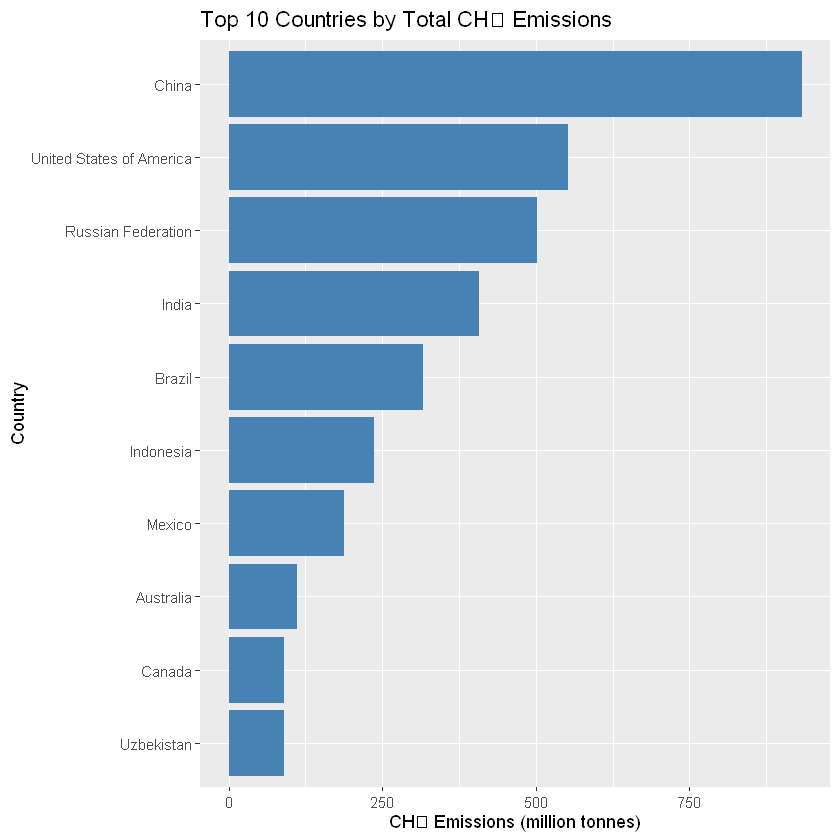

In [77]:
top_ch4 <- df %>% 
  arrange(desc(CH4.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, CH4.emissions), y = CH4.emissions)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total CH₄ Emissions",
       x = "Country", y = "CH₄ Emissions (million tonnes)")


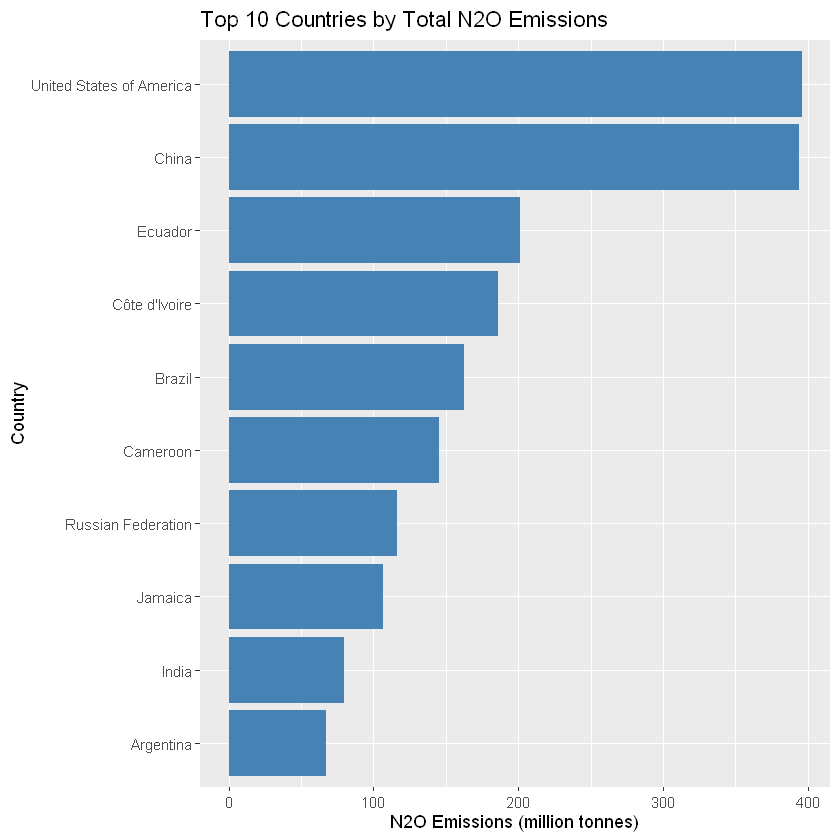

In [93]:
top_ch4 <- df %>% 
  arrange(desc(N2O.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, N2O.emissions), y = N2O.emissions)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total N2O Emissions",
       x = "Country", y = "N2O Emissions (million tonnes)")


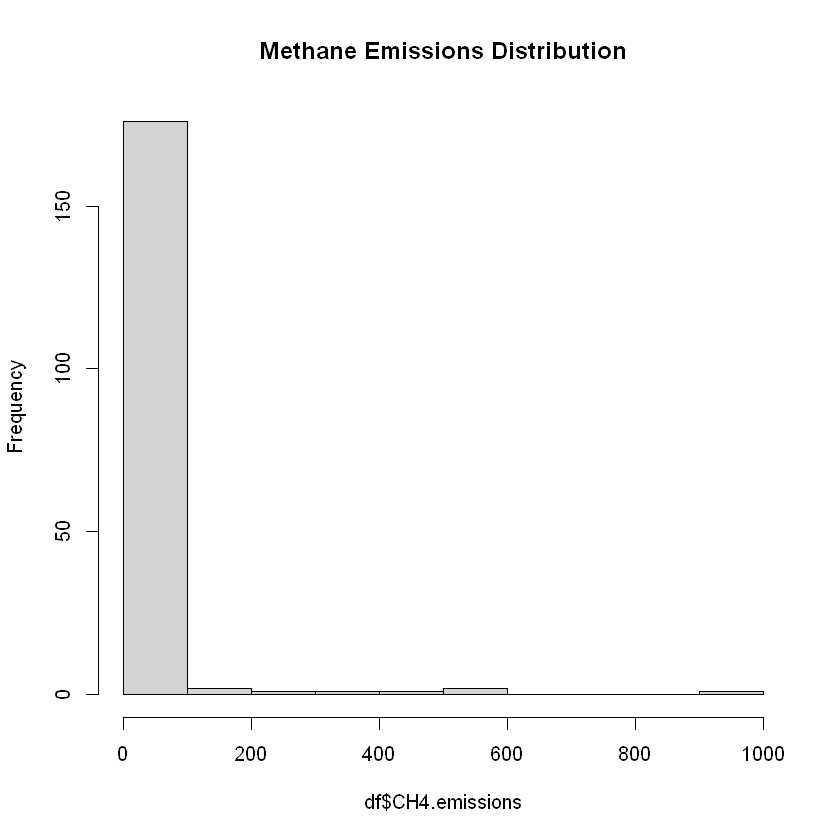

In [11]:
hist(df$CH4.emissions, main="Methane Emissions Distribution")

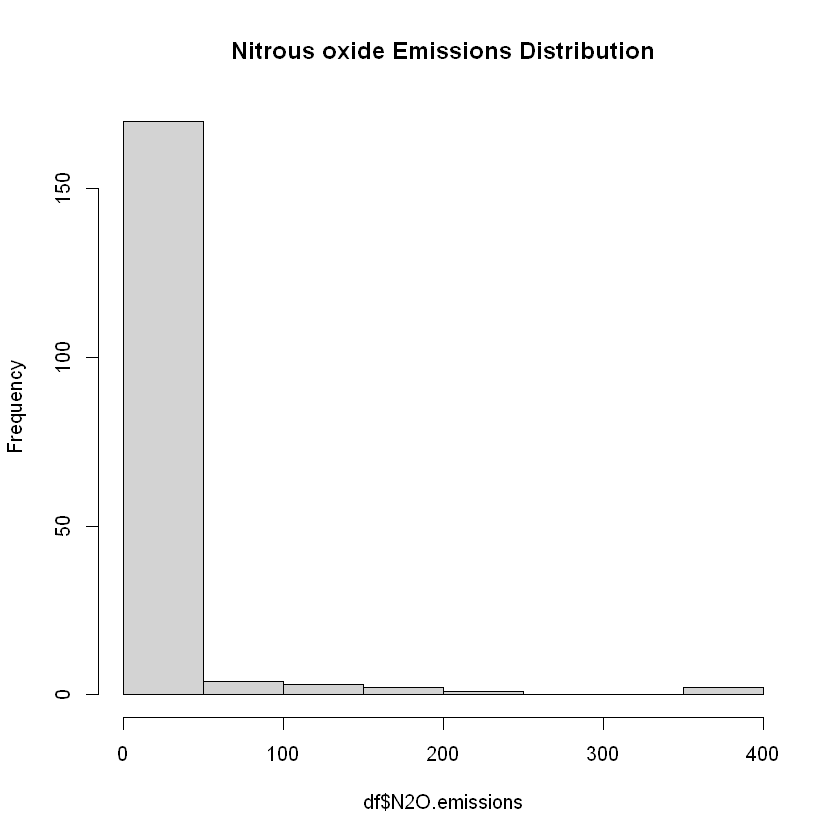

In [94]:
hist(df$N2O.emissions, main="Nitrous oxide Emissions Distribution")

In [66]:
#MILESTONE 2
df <- na.omit(df)

In [16]:
df$latest.year.available <- as.integer(df$latest.year.available)

In [30]:
df$Total_Emissions <- df$CH4.emissions + df$N2O.emissions

In [21]:
df_grouped <- df %>%
  group_by(Country) %>%
  summarise(CH4_mean = mean(CH4.emissions), N2O_mean = mean(N2O.emissions))

In [29]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X,Year,Total_Emissions,CH4_growth
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<dbl>,<dbl>


In [24]:
df <- df %>%
  group_by(Country) %>%
  mutate(CH4_growth = (CH4.emissions - lag(CH4.emissions)) / lag(CH4.emissions))